# Stiching of SANS curves

In [8]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import scarlet.reduction.stitching as st

def load_txt_curve(path: Path) -> st.SASCurve:
    """Load one ASCII I(Q) export with columns Q, I, dI, dQ."""
    data = np.loadtxt(path)
    data = data[data[:, 1] > 0]
    return st.SASCurve(
        data[:, 0],
        data[:, 1],
        data[:, 2],
        data[:, 3],
        name=path.stem,
        config_id=path.stem,
    )

def load_grasp_curve(path: Path) -> st.SASCurve:
    """Load one GRASP ASCII I(Q) export with columns Q, I, dI, dQ."""
    data = np.loadtxt(path, skiprows=40)
    data = data[data[:, 1] > 0]
    return st.SASCurve(
        data[:, 0],
        data[:, 1],
        data[:, 2],
        data[:, 3],
        name=path.stem,
        config_id=path.stem,
    )


def plot_curves(curves: tuple[st.SASCurve, ...]) -> None:
    """Plot the curves."""
    fig, ax = plt.subplots()
    for curve in curves:
        if hasattr(curve, "name"):
            name = curve.name
        else:
            name = ""
        ax.errorbar(
            curve.q,
            curve.i,
            yerr=curve.di,
            label=name,
            fmt="o",
            markersize=3,
        )
    ax.set_xlabel("Q (1/Å)")
    ax.set_ylabel("I(Q) (cm⁻¹)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    # plt.show()
    return fig, ax

## Data loading

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Q (1/Å)', ylabel='I(Q) (cm⁻¹)'>)

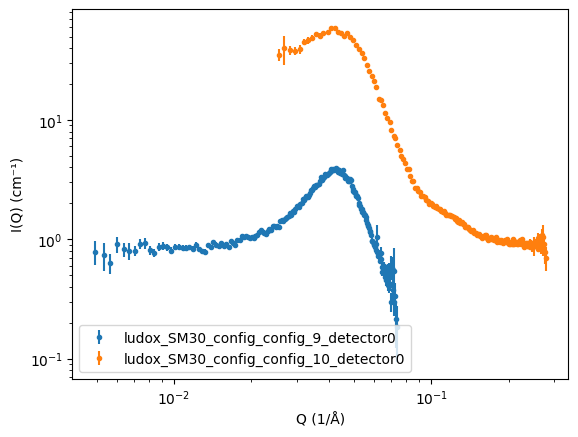

In [17]:
data_dir = Path("./data_SANS_LLB/")
curve_paths = (
    data_dir / "ludox_SM30_config_config_9_detector0.txt",
    data_dir / "ludox_SM30_config_config_10_detector0.txt",
)
curves = tuple(sorted((load_txt_curve(path) for path in curve_paths), key=lambda curve: curve.q.min()))

# data_dir = Path("./data_D11_AA0//")
# curve_paths = (
#     data_dir / "011334_001.dat",
#     data_dir / "011344_002.dat",
# )

# curves = tuple(sorted((load_grasp_curve(path) for path in curve_paths), key=lambda curve: curve.q.min()))



plot_curves(curves)

## find overlap

In [18]:
qmin, qmax = st.overlap_bounds(curves[0], curves[1], q_range=None)
print(f"Overlap bounds: {qmin:.3f} - {qmax:.3f} 1/Å")

Overlap bounds: 0.026 - 0.073 1/Å


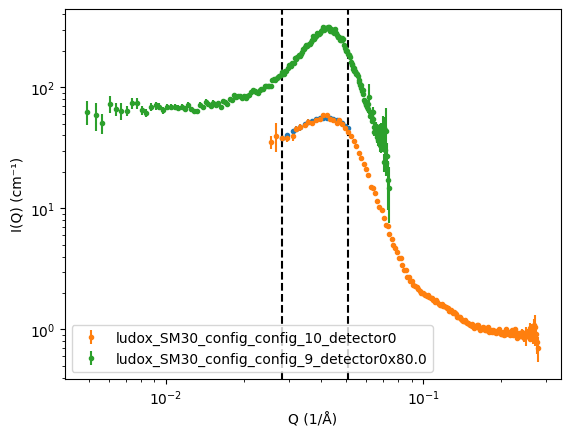

In [19]:
low_q_curve = curves[0]
high_q_curve = curves[1]
q_min, q_max = st.overlap_bounds(curves[0], curves[1], q_range=None)
low_mask = (low_q_curve.q >= q_min) & (low_q_curve.q <= q_max)
high_mask = (high_q_curve.q >= q_min) & (high_q_curve.q <= q_max)
q = high_q_curve.q[high_mask]
target_dq = high_q_curve.dq[high_mask]
low_q_degraded = st.degrade_to_resolution(low_q_curve, q_eval=q, target_dq=target_dq,
                         min_coverage=0.995,
                         resolution_rtol=0.10
                        )
fig, ax = plot_curves((low_q_degraded*20, high_q_curve, low_q_curve*80))
ax.axvline(np.min(low_q_degraded.q[low_q_degraded.valid]), color="k", ls="--")
ax.axvline(np.max(low_q_degraded.q[low_q_degraded.valid]), color="k", ls="--")
np.min(low_q_degraded.q[low_q_degraded.valid])
plt.show()

In [20]:
low_q_degraded.valid

array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

In [ ]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar


def interpolate_sascurve(curve: st.SASCurve, q_eval: np.ndarray) -> st.SASCurve:
    """Interpolate a SASCurve to new q values."""
    from scipy.interpolate import PchipInterpolator

    # Interpolate I and dI
    i_interp = PchipInterpolator(curve.q, curve.i, extrapolate=False)(q_eval)
    di_interp = PchipInterpolator(curve.q, curve.di, extrapolate=False)(q_eval)

    # Interpolate dq
    dq_interp = PchipInterpolator(curve.q, curve.dq, extrapolate=True)(q_eval)

    # Determine valid points (where interpolation is possible)

    return st.SASCurve(
        q=q_eval,
        i=i_interp,
        di=di_interp,
        dq=dq_interp,
        name=curve.name,
        config_id=curve.config_id,
    )

def cut_sascurve(curve: st.SASCurve, q_range: tuple[float,float] | None =None):
    if q_range is None:
        return curve
    else:
        mask = (curve.q >= q_range[0]) & (curve.q <= q_range[1])
        return st.SASCurve(q=curve.q[mask],i=curve.i[mask],
                           di=curve.di[mask], dq = curve.dq[mask],
                           name=curve.name,
                           config_id=curve.config_id,
                           )

def get_common_sascurves(curve: st.SASCurve, target_curve: st.SASCurve, q_range:tuple[float, float] | None = None) -> tuple[st.SASCurve, st.SASCurve]:
    q_min, q_max = st.overlap_bounds(curve, target_curve, q_range=q_range)
    
    target_curve_cut = cut_sascurve(target_curve, q_range=(q_min, q_max))   
    curve_interp = interpolate_sascurve(curve, q_eval=target_curve_cut.q)
    return curve_interp, target_curve_cut


from scipy.interpolate import PchipInterpolator
def conv_resol_fast(ith , q0, dq0=None, ni=15, nec=3):
    """
    Fast convolution of scattering data with Gaussian resolution.

    Parameters
    ----------
    ith : array_like
        Scattering intensity I(Q).
    q0 : array_like
        Q-values (same length as ith).
    dq0 : array_like or None
        Standard deviation of resolution at each Q. If None, no convolution is applied.
    ni : int
        Number of points in the Gaussian kernel (default: 15).
    nec : float
        Number of sigma (standard deviations) to include in kernel range (default: ±3).

    Returns
    -------
    iexp : ndarray
        Convolved intensity, same shape as ith.
    """

    if dq0 is None:
        return ith

    # Ensure correct shapes
    q0 = np.asarray(q0)
    ith = np.asarray(ith)
    dq0 = np.asarray(dq0).reshape((-1, 1))  # shape (nq, 1)

    u = np.linspace(-nec, nec, ni)  # relative position in units of sigma, shape (ni,)
    qMat = q0[:, None] + dq0 * u[None, :]  # shape (nq, ni)

    # Interpolate using fast monotonic PCHIP interpolator
    interp = PchipInterpolator(q0, ith, extrapolate=True)
    fMat = interp(qMat)  # shape (nq, ni)

    # Gaussian kernel
    weights = np.exp(-0.5 * u**2)
    weights /= np.sum(weights)  # normalize

    # Weighted sum over the kernel
    iexp = fMat @ weights  # shape (nq,)

    return iexp


def convResol(ith,q0,dq0):
    if dq0 is None:
        return ith
    ni=21
    nec=3
    dq0=dq0.reshape((len(dq0),1))
    u=np.linspace(-nec,nec,ni)
    u=u.reshape(1,ni)
    qMat=np.transpose(np.dot(dq0,u))+q0
    qMat=qMat.transpose()
    f=interp1d(q0, ith, kind='cubic',
               fill_value=(ith[0],ith[-1]),
               bounds_error=False)
    fMat=f(qMat)
    pdei=np.exp(-u**2/2)
    pdei=pdei/np.sum(pdei)
    iexp=fMat.dot(pdei.transpose())
    return iexp.reshape(len(q0),)

def common_q_range(curves: tuple[st.SASCurve, ...]) -> tuple[float, float]:
    """Determine the common q range for a set of SASCurves."""
    q_min = max(curve.q.min() for curve in curves)
    q_max = min(curve.q.max() for curve in curves)
    return q_min, q_max

def degrade_resol(curve: st.SASCurve, target_curve: st.SASCurve, alpha: float=1):
    target_dq = np.sqrt(target_curve.dq**2 - curve.dq**2)*alpha
    i = convResol(curve.i, curve.q, dq0=target_dq)
    i_conv = st.SASCurve(
    q=curve.q,
    i=i,
    di=curve.di,  # Assuming di remains the same; adjust if needed
    dq=target_dq,
    name=curve.name + "degraded",
    config_id=curve.config_id,
)
    return i_conv

def flatness_ratio(curve: st.SASCurve, target_curve: st.SASCurve):
    y = np.log(curve.i)-np.log(target_curve.i)
    sigy2 = (curve.di/curve.i)**2 + (target_curve.di/target_curve.i)**2
    m_alpha = np.sum(y/sigy2)/np.sum(1/sigy2)
    score = 1/(len(y)-1) * np.sum((y-m_alpha)**2/sigy2)
    return score


def fit_alpha(curve: st.SASCurve, target_curve: st.SASCurve, fit_range: tuple[float, float] | None = None):
    curve_interp, curve_target_cut = get_common_sascurves(curve, target_curve, q_range=fit_range)
    
    def objective(alpha: float):
        curve_degraded = degrade_resol(curve_interp, 
                                       curve_target_cut,
                                       alpha=alpha
                                       )
        return flatness_ratio(curve_degraded, curve_target_cut)
    
    opt = minimize_scalar(
        objective,
        bounds=(0.2,1),
        method="bounded",
    )
    return float(opt.x), opt.success

def fit_prefactor(curve: st.SASCurve, target_curve: st.SASCurve, fit_range: tuple[float, float] | None = None) -> tuple[float, float]:
    alpha_opt, success = fit_alpha(curve, target_curve, fit_range=fit_range)
    curve_interp, curve_target_cut = get_common_sascurves(curve, target_curve, q_range=fit_range)
    curve_degraded = degrade_resol(curve_interp, curve_target_cut, alpha=alpha_opt)

    sigy2 = (curve_degraded.di/curve_degraded.i)**2 + (curve_target_cut.di/curve_target_cut.i)**2
    y = np.log(curve_degraded.i)-np.log(curve_target_cut.i)
    m = np.sum(y/sigy2) / np.sum(1/sigy2)
    s = np.exp(m)
    sigm = np.sum(1/sigy2)**(-0.5)
    sigs = s * sigm
    # def objecive(s: float):
    #     sigy2 = (curve_degraded.di/curve_degraded.i)**2 + (curve_target_cut.di/curve_target_cut.i)**2
    #     y = np.log(curve.i)-np.log(target_curve.i)
    #     return np.sum((curve_degraded.i-curve_target_cut.i)**2 / sigy2)

    return [s, sigs]

def log_ratio(curve: st.SASCurve, target_curve: st.SASCurve):
    sigy2 = (curve.di/curve.i)**2 + (target_curve.di/target_curve.i)**2
    y = np.log(curve.i)-np.log(target_curve.i)
    return y, sigy2

def weighted_slope(x,y,yerr):
    weights = 1.0 / yerr**2
    x0 = np.sum(weights * x) / np.sum(weights)
    y0 = np.sum(weights * y) / np.sum(weights)
    dx = x - x0
    dy = y - y0

    slope = np.sum(weights * dx * dy) / np.sum(weights * dx**2)

    slope_error = np.sqrt(1.0 / np.sum(weights * dx**2))

    return slope, slope_error



def fit_prefactor_bis(curve: st.SASCurve, target_curve: st.SASCurve, fit_range: tuple[float, float] | None = None) -> tuple[float, float]:
    curve_interp, curve_target_cut = get_common_sascurves(curve, target_curve, q_range=fit_range)
    y, sig2

    return

In [22]:
fit_alpha(low_q_curve, high_q_curve, fit_range=[0.04,0.06])

(0.7239817499382858, True)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Q (1/Å)', ylabel='I(Q) (cm⁻¹)'>)

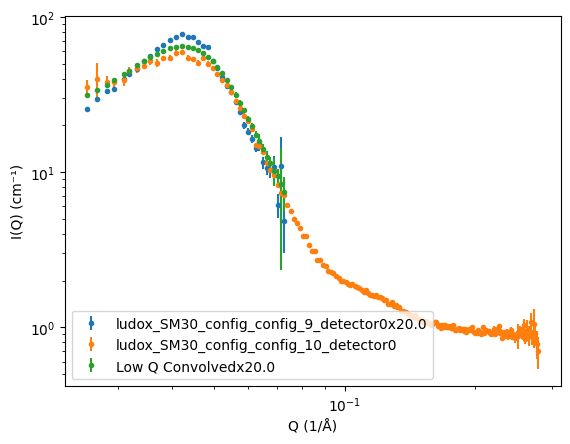

In [23]:
q = high_q_curve.q[high_mask]
low_q_interp = interpolate_sascurve(low_q_curve, q_eval=q)
target_dq = np.sqrt(high_q_curve.dq[high_mask]**2 - low_q_interp.dq**2)*0.64
i_conv = convResol(low_q_interp.i, q, dq0=target_dq)
i_low_conv = st.SASCurve(
    q=q,
    i=i_conv,
    di=low_q_interp.di,  # Assuming di remains the same; adjust if needed
    dq=target_dq,
    name="Low Q Convolved",
    config_id=low_q_interp.config_id,
)
f = 20
plot_curves((low_q_interp*f, high_q_curve, i_low_conv*f))

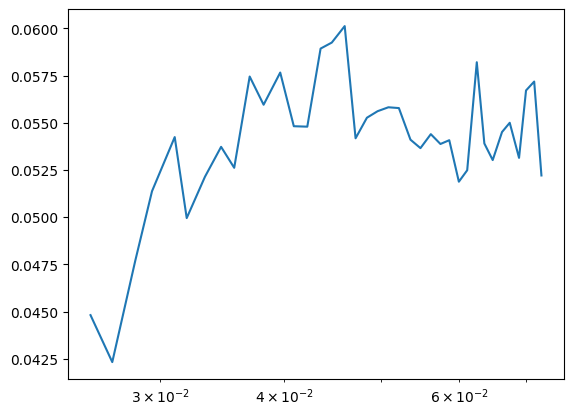

In [24]:
plt.semilogx(q, i_low_conv.i/high_q_curve.i[high_mask])

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Q (1/Å)', ylabel='I(Q) (cm⁻¹)'>)

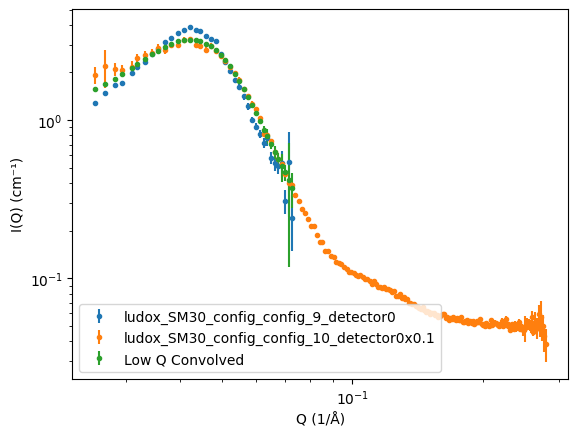

In [25]:
s, sigs = fit_prefactor(low_q_curve, high_q_curve)
plot_curves((low_q_interp, high_q_curve*s, i_low_conv))

In [ ]:
s

np.float64(0.9901783268320016)

In [ ]:
sigs

np.float64(0.006753345973179346)